# HY Fysiska vatten — anlagda objekt / HY Physical Waters — Man-Made Objects

## En kvalitetsmedveten rapport om Sveriges dammregister / A quality-aware report on Sweden’s dam register

Rapporten undersöker svenska dammenheters geografiska fördelning, status, konstruktion, verksamhet, dimensioner, ekologiska konnektivitet och vattendistrikt. Den centrala metodregeln är enkel: **rensa varje variabel utifrån dess dokumenterade betydelse innan den analyseras**. Källans råfält bevaras alltid tillsammans med härledda, rensade fält och kvalitetsflaggor.

Dammdata kommer från [SMHI:s SE.HY Dammregistret](https://www.smhi.se/data/sok-oppna-data-i-utforskaren/se-hy-dammregistret). Länsgränser kommer från [SCB:s digitala gränser](https://www.scb.se/hitta-statistik/regional-statistik-och-kartor/regionala-indelningar/digitala-granser/).

## Sammanfattning / Executive summary

- Registret innehåller **dammenheter**, inte nödvändigtvis en rad per fullständig dammanläggning. En anläggning kan bestå av flera dammenheter.
- Kodade nollor betyder ofta *ej angivet*, inte det fysiska värdet noll. Detta påverkar dimensioner, konstruktion, verksamhet, fiskväg, vandringshinder och höjdsystem.
- `dammhojd` är dammhöjd. Flera extremvärden ligger nära absoluta magasinsnivåer (`dg` eller `sg`) och flaggas därför som sannolika felregistrerade höjdnivåer.
- `kron` betyder **krönlängd**, inte krönbredd. Långa fyllningsdammar tas därför inte bort enbart för att längden överstiger en kilometer.
- Trängsletdammen finns i registret, men både dammhöjd och krönlängd är registrerade som noll—i praktiken saknade värden. Registret kan därför inte ensamt användas för att rangordna Sveriges högsta dammar.
- Fälten för fiskväg och vandringshinder har omfattande bortfall. Andelar bland rapporterade rader får inte presenteras som nationell förekomst.

## 1. Miljö och reproducerbarhet / Environment and reproducibility

Rapporten använder GeoPandas, pandas, NumPy, Matplotlib och Plotly. Diagrammen i avsnitt 7 är interaktiva Plotly-figurer och sparas även som fristående HTML-filer i `geo/manmade_water_report_figures/`; övriga figurer sparas som PNG i samma mapp.

In [1]:
from pathlib import Path
import unicodedata

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents] if (folder / "geo/HY_PhysicalWaters_ManMadeObject").exists())
GEO_DIR = ROOT / "geo"
DAM_PATH = GEO_DIR / "HY_PhysicalWaters_ManMadeObject/HY_PhysicalWaters_ManMadeObject.shp"
COUNTY_PATH = GEO_DIR / "shape_svenska_260225/LanSweref99TM.zip"
FIGURE_DIR = GEO_DIR / "manmade_water_report_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {"ink": "#24323D", "muted": "#718096", "water": "#DDEEF5", "blue": "#246B8E", "teal": "#1F9D8A", "gold": "#E4A11B", "rose": "#C64B7B", "purple": "#7251A3", "grey": "#A8B0B8", "background": "#FBFAF7"}
plt.rcParams.update({"figure.facecolor": COLORS["background"], "axes.facecolor": COLORS["background"], "axes.edgecolor": "#D7DCE0", "axes.labelcolor": COLORS["ink"], "text.color": COLORS["ink"], "font.family": "DejaVu Sans", "font.size": 10})

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
    return path

## 2. Läs in och validera källfilerna / Load and validate the source files

Shapefilen innehåller punktgeometrier i SWEREF 99 TM (EPSG:3006). Valideringen är strukturell: koordinatsystem, antal rader, unika ID:n och användbar geometri. Inga källvärden ändras.

In [2]:
raw = gpd.read_file(DAM_PATH, encoding="utf-8")
counties = gpd.read_file(f"zip://{COUNTY_PATH.resolve()}")
if raw.crs != counties.crs:
    raw = raw.to_crs(counties.crs)
validation = pd.Series({"Rader": len(raw), "Kolumner inklusive geometri": len(raw.columns), "Koordinatsystem": str(raw.crs), "Duplicerade dammid": int(raw["dammid"].duplicated().sum()), "Saknad geometri": int(raw.geometry.isna().sum()), "Ogiltig geometri": int((~raw.geometry.is_valid).sum())})
display(validation.to_frame("Värde"))

,Värde
Rader,10702
Kolumner inklusive geometri,36
Koordinatsystem,EPSG:3006
Duplicerade dammid,0
Saknad geometri,0
Ogiltig geometri,0


### Central dataordlista / Core data dictionary

Definitionerna följer [SMHI:s dokumentation av SVAR:s dammregister](https://www.smhi.se/download/18.18f5a56618fc9f08e832ac0b/1717802120343/Hydrologi_128%20Arbete%20med%20SVAR%20version%202016%2C%20Svenskt%20vattenarkiv%2C%20en%20databas%20vid%20SMHI.pdf). Kod `0` förekommer i exporten som ej angivet värde, men är inte alltid en uttryckligen definierad kategori i SMHI:s kodlista.

| Fält | Exakt betydelse / kodning | Rensningsprincip |
|---|---|---|
| `dammid` | Unik identitet för dammenheten | Ska vara unik och får inte skrivas över |
| `dnamn` / `namn` | Dammenhetens namn / dammanläggningens namn | Använd `dnamn`, annars `namn`; saknas båda anges *Namnlös dammenhet* |
| `status` | `1` = befintlig damm; `2` = före detta damm | Andra koder flaggas som ogiltiga |
| `regl_typ`, befintlig damm | `1` = fast tröskel/överfall; `2` = reglerbart utskov; `3` = intag; `4` = spärrdamm/oreglerad | Tolkningen måste kombineras med `status=1`; `0` behandlas som ej angivet |
| `regl_typ`, före detta damm | `1` = raserad; `2` = utriven | Tolkningen måste kombineras med `status=2`; `0` behandlas som ej angivet |
| `konstr` | `1` = fyllningsdamm; `2` = betong; `3` = murverk; `4` = spont; `5` = annan | `0` behandlas som ej angivet |
| `verksmht` | `1` = kraftproduktion; `2` = industri; `3` = sjöfart; `4` = invallning; `5` = vattenförsörjning; `6` = spegeldamm; `7` = historisk; `8` = övrigt | `0` behandlas som ej angivet |
| `byggar` / `ombyggar` | År för första byggnation / år då anläggningen togs i drift i nuvarande utformning | `0` behandlas som saknat årtal |
| `dammhojd` | Dammens högsta höjd i meter: skillnaden mellan grundläggningens djupaste del och dammens krön | `0` behandlas som saknat; extremvärden jämförs med `dg` och `sg` |
| `kron` | Dammkrönets **längd** i meter, inte bredd | `0` behandlas som saknat; långa värden granskas men tas inte automatiskt bort |
| `dg` / `sg` | Högsta dämningsgräns / lägsta sänkningsgräns enligt tillstånd, i det höjdsystem som anges av `hojd_sys` | Absoluta nivåer; `0` behandlas som saknat |
| `hojd_sys` | `1` = RH2000; `2` = lokalt höjdsystem | `0` behandlas som ej angivet; koder `3` och `4` finns i exporten men saknar definition i den citerade kodlistan och flaggas för granskning |
| `my` / `rv` | Magasinsyta i km² vid angiven `dg` / reglerbar volym i miljoner m³ mellan `dg` och `sg` | `0` behandlas som saknat |
| `fiskvag` | `1` = bassängtrappa; `2` = Denilränna; `3` = slitsränna; `4` = omlöp; `5` = inlöp; `6` = ålledare; `7` = smoltränna; `8` = okänd typ; `9` = ingen fiskväg; `10` = annat | `0` behandlas som ej angivet |
| `fiskavl` | `1` = ja; `2` = nej; `3` = okänt | `0` behandlas som ej angivet |
| `vhinder` | `1` = ja, dammenheten är ett vandringshinder; `2` = nej | `0` behandlas som ej angivet |
| `rbd` | `SE1` = Bottenvikens; `SE2` = Bottenhavets; `SE3` = Norra Östersjöns; `SE4` = Södra Östersjöns; `SE5` = Västerhavets vattendistrikt | Svenska distriktskoder extraheras; gränsöverskridande specialkoder bevaras separat |

### Regleringstyper för befintliga dammar / Regulation types for existing dams
<p align="center">
  <img src="regleringstyper_befintliga_dammar_1080.webp"
       alt="Regleringstyper"
       width="720">
</p>

### Konstruktion för befintliga dammar / Construction types for existing dams

<p align="center">
  <img src="konstruktion_befintlig_damm_720.webp"
       alt="Konstruktionstyper"
       width="720">
</p>

## 3. Gemensam grundrensning / Common baseline cleaning

Detta steg skapar analysfält utan att skriva över råattributen. Namn normaliseras, gemensamma koder valideras, numeriska kolumner konverteras och projicerade koordinater härleds. Variabelspecifik rensning görs i respektive analysavsnitt.

In [3]:
dams = raw.copy()
numeric_columns = ["dammhojd", "kron", "byggar", "ombyggar", "dg", "sg", "my", "rv"]
for column in numeric_columns:
    dams[f"{column}_raw"] = pd.to_numeric(dams[column], errors="coerce")
bad_name_tokens = {"", "1", "2", "nan", "none"}
unit_name = dams["dnamn"].astype("string").str.strip()
facility_name = dams["namn"].astype("string").str.strip()
unit_name = unit_name.mask(unit_name.str.casefold().isin(bad_name_tokens))
facility_name = facility_name.mask(facility_name.str.casefold().isin(bad_name_tokens))
dams["display_name"] = unit_name.fillna(facility_name).fillna("Namnlös dammenhet")
dams["x"] = dams.geometry.x
dams["y"] = dams.geometry.y

STATUS = {1: "Befintlig", 2: "Före detta"}
CONSTRUCTION = {0: "Ej angivet", 1: "Fyllningsdamm", 2: "Betong", 3: "Murverk", 4: "Spont", 5: "Annan"}
ACTIVITY = {0: "Ej angivet", 1: "Kraftproduktion", 2: "Industri", 3: "Sjöfart", 4: "Invallning", 5: "Vattenförsörjning", 6: "Spegeldamm", 7: "Historisk", 8: "Övrigt"}
EXISTING_REGULATION = {0: "Ej angivet", 1: "Fast tröskel / överfall", 2: "Reglerbart utskov", 3: "Intag", 4: "Spärrdamm / oreglerad"}
FORMER_REGULATION = {0: "Ej angivet", 1: "Raserad", 2: "Utriven"}
dams["status_clean"] = dams["status"].map(STATUS).fillna("Ogiltig kod")
dams["construction_clean"] = dams["konstr"].map(CONSTRUCTION).fillna("Ogiltig kod")
dams["activity_clean"] = dams["verksmht"].map(ACTIVITY).fillna("Ogiltig kod")
dams["regulation_clean"] = np.where(dams["status"].eq(1), dams["regl_typ"].map(EXISTING_REGULATION), dams["regl_typ"].map(FORMER_REGULATION))
dams["regulation_clean"] = pd.Series(dams["regulation_clean"], index=dams.index).fillna("Ogiltig kod")
existing = dams.loc[dams["status_clean"].eq("Befintlig")].copy()
former = dams.loc[dams["status_clean"].eq("Före detta")].copy()

## 4. Datatäckning / Data completeness

**Avsnittsspecifik rensning:** ett fält räknas som rapporterat endast när det uppfyller sina egna kodningsregler. Positiva mätvärden räknas som rapporterade; kategorikod 0 räknas som ej angivet. Därmed behandlas inte platshållarvärdet noll som en verklig observation.

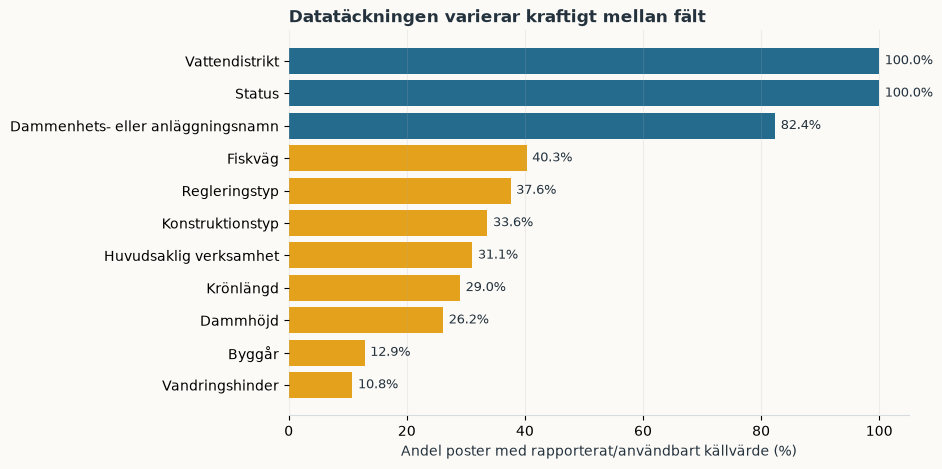

,rapporterat
Vandringshinder,10.8%
Byggår,12.9%
Dammhöjd,26.2%
Krönlängd,29.0%
Huvudsaklig verksamhet,31.1%
Konstruktionstyp,33.6%
Regleringstyp,37.6%
Fiskväg,40.3%
Dammenhets- eller anläggningsnamn,82.4%
Status,100.0%


In [4]:
coverage = pd.Series({"Dammenhets- eller anläggningsnamn": dams["display_name"].ne("Namnlös dammenhet").mean(), "Status": dams["status"].isin([1, 2]).mean(), "Regleringstyp": dams["regl_typ"].gt(0).mean(), "Konstruktionstyp": dams["konstr"].gt(0).mean(), "Huvudsaklig verksamhet": dams["verksmht"].gt(0).mean(), "Byggår": dams["byggar_raw"].between(1000, 2100).mean(), "Dammhöjd": dams["dammhojd_raw"].gt(0).mean(), "Krönlängd": dams["kron_raw"].gt(0).mean(), "Fiskväg": dams["fiskvag"].gt(0).mean(), "Vandringshinder": dams["vhinder"].isin([1, 2]).mean(), "Vattendistrikt": dams["rbd"].notna().mean()}).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(coverage.index, coverage.mul(100), color=np.where(coverage < 0.5, COLORS["gold"], COLORS["blue"]))
ax.bar_label(bars, labels=[f"{value:.1f}%" for value in coverage.mul(100)], padding=4, fontsize=9)
ax.set_xlim(0, 105); ax.set_xlabel("Andel poster med rapporterat/användbart källvärde (%)")
ax.set_title("Datatäckningen varierar kraftigt mellan fält", loc="left", weight="bold")
ax.spines[["top", "right", "left"]].set_visible(False); ax.grid(axis="x", alpha=0.18)
save_figure(fig, "01_data_completeness.png"); plt.show()
coverage_table = coverage.mul(100).round(1).astype(str).add("%").rename("rapporterat").to_frame()
display(coverage_table)

Diagrammet är en viktig kvalitetskontroll: senare andelar redovisas alltid tillsammans med mängden saknad information.

## 5. Rumslig översikt och status / Spatial overview and status

**Avsnittsspecifik rensning:** `status=1` betyder befintlig och `status=2` betyder före detta. Geometrin är komplett, så alla strukturellt giltiga rader kan visas. Små halvtransparenta punkter minskar överritning.

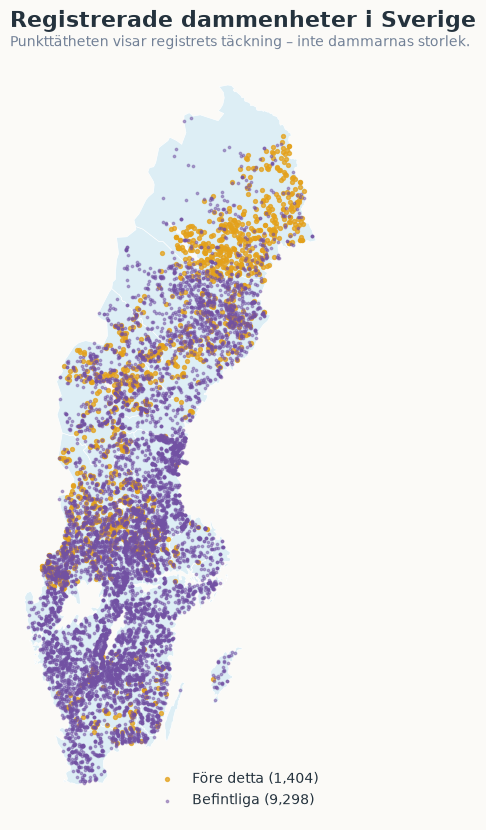

In [5]:
fig, ax = plt.subplots(figsize=(6, 10))
counties.plot(ax=ax, facecolor=COLORS["water"], edgecolor="white", linewidth=0.45)
former.plot(ax=ax, color=COLORS["gold"], markersize=8, alpha=0.75, label=f"Före detta ({len(former):,})", zorder=2)
existing.plot(ax=ax, color=COLORS["purple"], markersize=3, alpha=0.48, label=f"Befintliga ({len(existing):,})", zorder=3)
ax.set_title("Registrerade dammenheter i Sverige", loc="left", fontsize=16, weight="bold")
ax.text(0, 1.005, "Punkttätheten visar registrets täckning – inte dammarnas storlek.", transform=ax.transAxes, color=COLORS["muted"])
ax.legend(frameon=False, loc="lower right"); ax.set_axis_off()
save_figure(fig, "02_spatial_overview.png"); plt.show()

## 6. Reglering, konstruktion och verksamhet / Regulation, construction, and activity

**Avsnittsspecifik rensning:** regleringskoder avkodas separat för befintliga och före detta dammar eftersom samma sifferkod har olika betydelse. Kod 0 för konstruktion och verksamhet blir `Ej angivet`; kategorin visas så att bortfallet inte döljs. Värmekartan använder endast befintliga dammar där båda fälten är rapporterade.

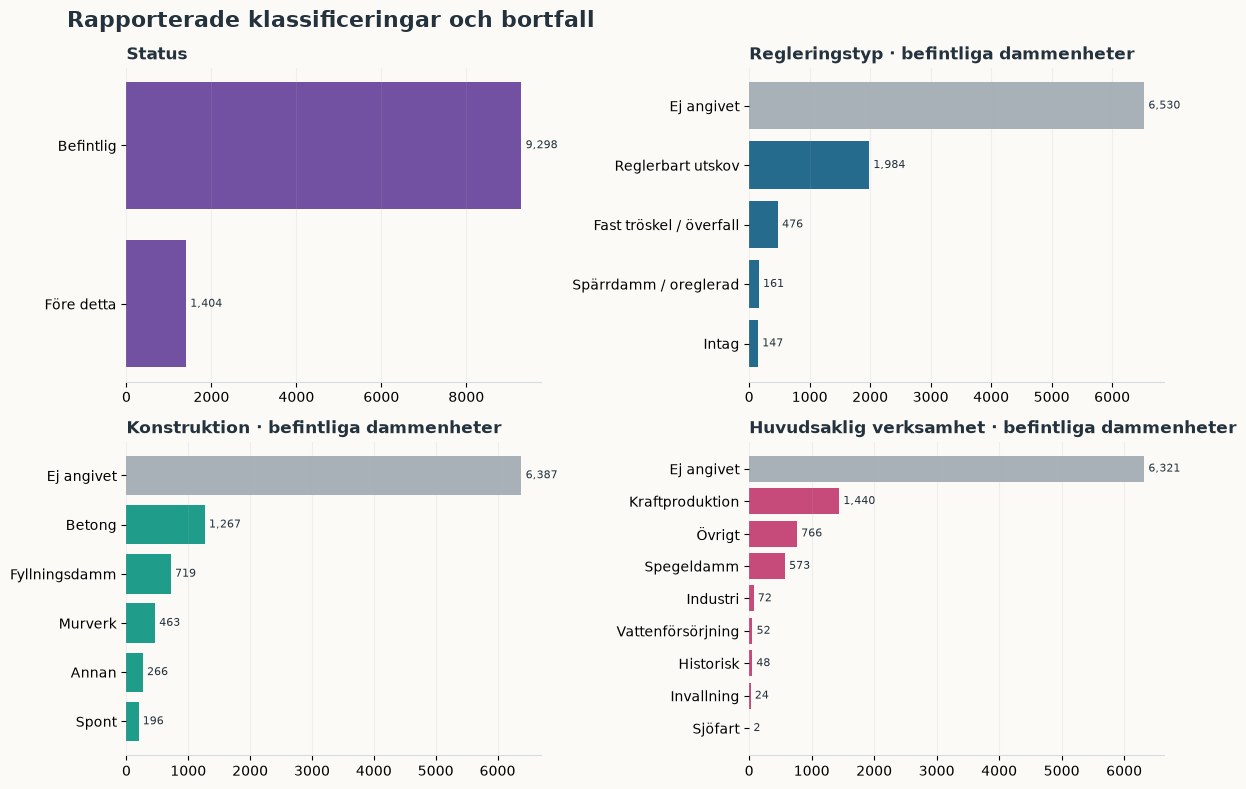

In [6]:
def horizontal_counts(ax, series, title, known_color):
    counts = series.value_counts().sort_values()
    colors = [COLORS["grey"] if label in {"Ej angivet", "Ogiltig kod"} else known_color for label in counts.index]
    bars = ax.barh(counts.index, counts.values, color=colors)
    ax.bar_label(bars, labels=[f"{value:,}" for value in counts.values], padding=3, fontsize=8)
    ax.set_title(title, loc="left", weight="bold"); ax.spines[["top", "right", "left"]].set_visible(False); ax.grid(axis="x", alpha=0.15)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
horizontal_counts(axes[0, 0], dams["status_clean"], "Status", COLORS["purple"])
horizontal_counts(axes[0, 1], existing["regulation_clean"], "Regleringstyp · befintliga dammenheter", COLORS["blue"])
horizontal_counts(axes[1, 0], existing["construction_clean"], "Konstruktion · befintliga dammenheter", COLORS["teal"])
horizontal_counts(axes[1, 1], existing["activity_clean"], "Huvudsaklig verksamhet · befintliga dammenheter", COLORS["rose"])
fig.suptitle("Rapporterade klassificeringar och bortfall", x=0.06, ha="left", fontsize=16, weight="bold"); fig.tight_layout()
save_figure(fig, "03_classification_counts.png"); plt.show()

### Geografisk fördelning av klassificeringarna / Geographic distribution of classifications

Kartorna visar befintliga dammenheter och använder samma rensade kategorier som stapeldiagrammen ovan. `Ej angivet` visas i grått och ligger underst, så att rapporterade kategorier förblir synliga utan att bortfallet döljs.

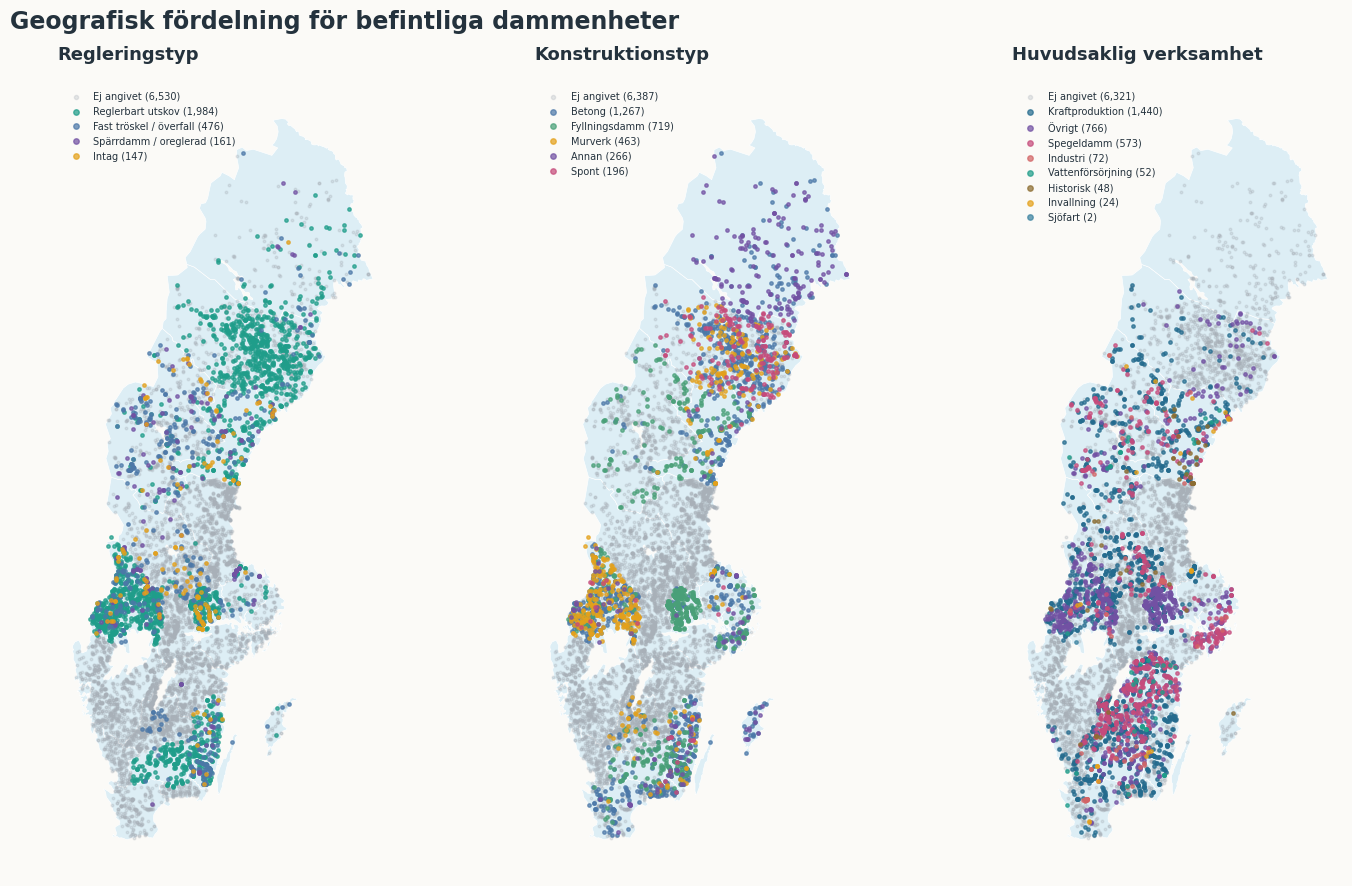

In [170]:
REGULATION_MAP_COLORS = {
    "Ej angivet": COLORS["grey"], "Fast tröskel / överfall": "#4C78A8",
    "Reglerbart utskov": "#1F9D8A", "Intag": "#E4A11B",
    "Spärrdamm / oreglerad": "#7251A3", "Ogiltig kod": "#24323D"
}
CONSTRUCTION_MAP_COLORS = {
    "Ej angivet": COLORS["grey"], "Fyllningsdamm": "#49A078", "Betong": "#4C78A8",
    "Murverk": "#E4A11B", "Spont": "#C64B7B", "Annan": "#7251A3",
    "Ogiltig kod": "#24323D"
}
ACTIVITY_MAP_COLORS = {
    "Ej angivet": COLORS["grey"], "Kraftproduktion": "#246B8E", "Industri": "#D26466",
    "Sjöfart": "#3B82A0", "Invallning": "#E4A11B", "Vattenförsörjning": "#1F9D8A",
    "Spegeldamm": "#C64B7B", "Historisk": "#8C6D31", "Övrigt": "#7251A3",
    "Ogiltig kod": "#24323D"
}

def categorical_dam_map(ax, data, field, title, palette):
    counties.plot(ax=ax, facecolor=COLORS["water"], edgecolor="white", linewidth=0.45)
    labels = [label for label in palette if data[field].eq(label).any()]
    labels = sorted(labels, key=lambda label: (label != "Ej angivet", -int(data[field].eq(label).sum())))
    for zorder, label in enumerate(labels, start=2):
        subset = data.loc[data[field].eq(label)]
        subset.plot(ax=ax, color=palette[label], markersize=3.5 if label == "Ej angivet" else 6, alpha=0.28 if label == "Ej angivet" else 0.72, label=f"{label} ({len(subset):,})", zorder=zorder)
    ax.set_title(title, loc="left", fontsize=13, weight="bold")
    ax.legend(frameon=False, fontsize=7, loc="upper left", markerscale=1.6)
    ax.set_axis_off()

fig, axes = plt.subplots(1, 3, figsize=(15, 9))
categorical_dam_map(axes[0], existing, "regulation_clean", "Regleringstyp", REGULATION_MAP_COLORS)
categorical_dam_map(axes[1], existing, "construction_clean", "Konstruktionstyp", CONSTRUCTION_MAP_COLORS)
categorical_dam_map(axes[2], existing, "activity_clean", "Huvudsaklig verksamhet", ACTIVITY_MAP_COLORS)
fig.suptitle("Geografisk fördelning för befintliga dammenheter", x=0.04, ha="left", fontsize=17, weight="bold")
fig.tight_layout(); save_figure(fig, "03b_classification_maps.png"); plt.show()

In [175]:
existing.head(1)

,dammid,lst_objid,north,east,datum,dnamn,status,regl_typ,konstr,byggar,...,sg_raw,my_raw,rv_raw,display_name,x,y,status_clean,construction_clean,activity_clean,regulation_clean
0,{1CD63311-EF6D-4694-BB76-97754D76CE67},3_1__2012,6716679.0,633862.0,2012-03-07,Älvkarleby,1,0,0,1915,...,0.0,0.0,0.0,Älvkarleby,633862.8623,6.716680e+06,Befintlig,Ej angivet,Kraftproduktion,Ej angivet


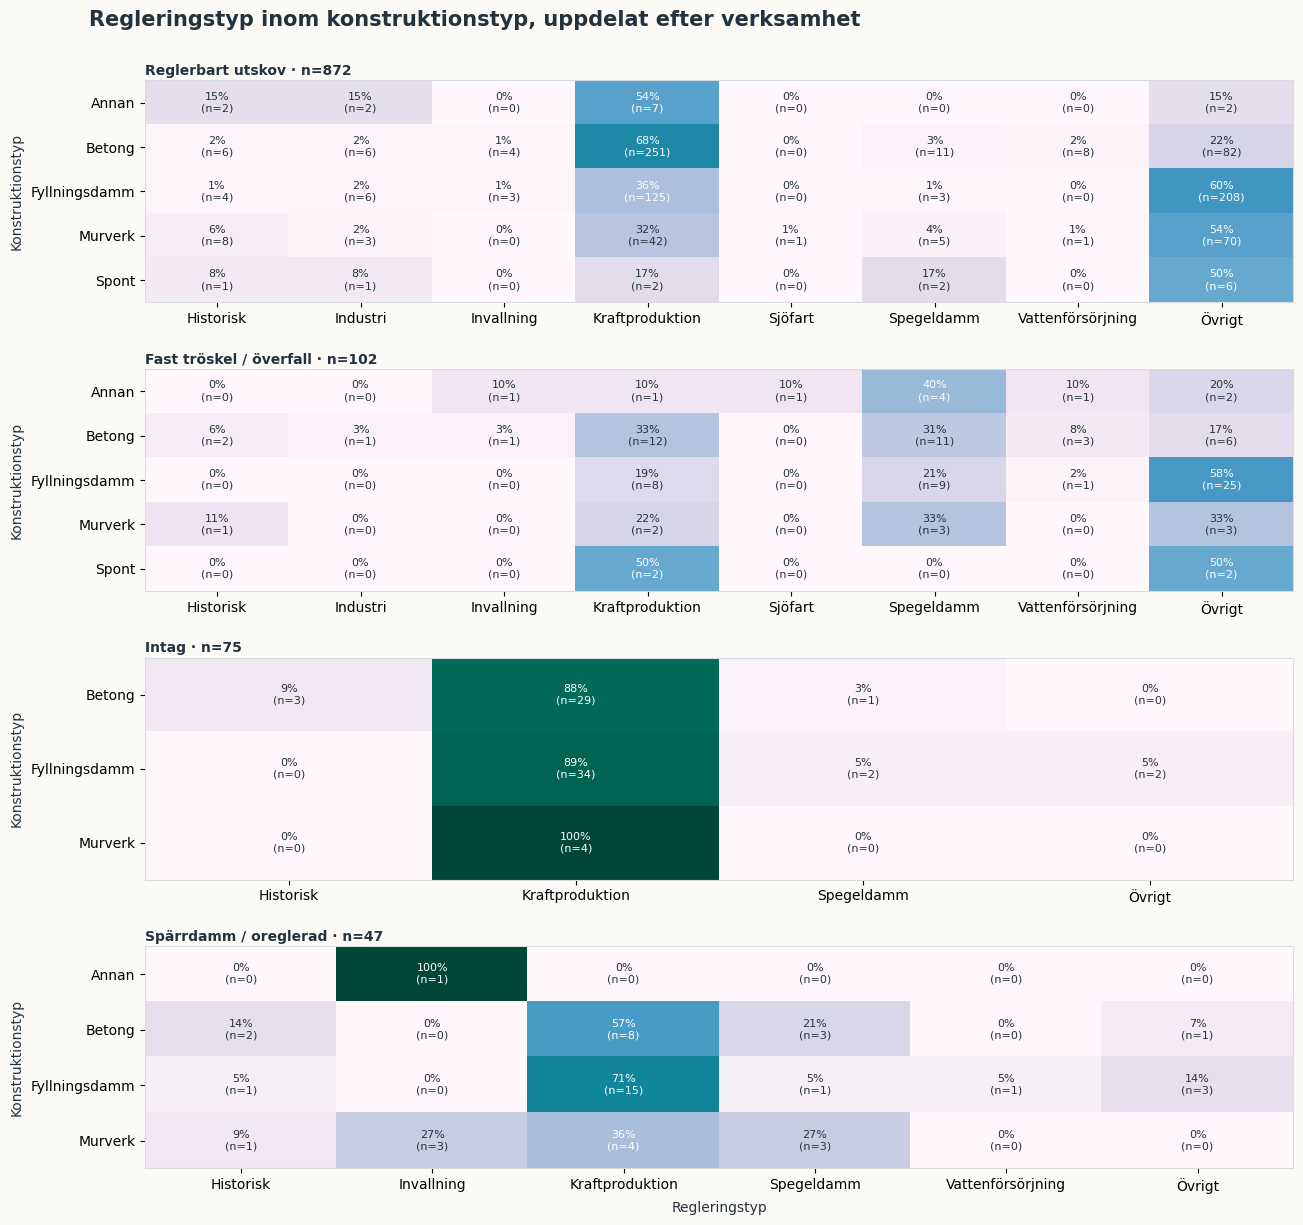

In [214]:
known_types = existing.loc[
    existing["construction_clean"].ne("Ej angivet")
    & existing["regulation_clean"].ne("Ej angivet")
    & existing["activity_clean"].ne("Ej angivet")
].copy()

regulations = known_types["regulation_clean"].value_counts().index.tolist()

ncols = 1
nrows = int(np.ceil(len(regulations) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 3.2 * nrows),
    squeeze=False
)

for i, (ax, regulation) in enumerate(zip(axes.flat, regulations)):

    subset = known_types.loc[known_types["regulation_clean"].eq(regulation)]

    relationship = pd.crosstab(
        subset["construction_clean"],
        subset["activity_clean"]
    )

    row_share = relationship.div(
        relationship.sum(axis=1), axis=0
    ).mul(100)

    image = ax.imshow(
        row_share,
        cmap="PuBuGn",
        vmin=0,
        vmax=100,
        aspect="auto"
    )

    ax.set_xticks(
        range(len(row_share.columns)),
        row_share.columns,
        rotation=0,
        ha="center"
    )

    ax.set_yticks(
        range(len(row_share.index)),
        row_share.index
    )

    for row in range(row_share.shape[0]):
        for col in range(row_share.shape[1]):

            value = row_share.iat[row, col]
            count = relationship.iat[row, col]

            ax.text(
                col, row,
                f"{value:.0f}%\n(n={count:,})",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if value > 35 else COLORS["ink"]
            )

    ax.set_title(
        f"{regulation} · n={len(subset):,}",
        loc="left",
        fontsize=10,
        weight="bold",
        pad=4
    )

    row_idx = i // ncols
    col_idx = i % ncols

    # Only bottom row gets x-axis label
    ax.set_xlabel(
        "Regleringstyp" if row_idx == nrows - 1 else "",
        labelpad=5
    )

    # Only left column gets y-axis label
    ax.set_ylabel(
        "Konstruktionstyp" if col_idx == 0 else "",
        labelpad=5
    )

    # Hide duplicated tick labels
    if col_idx != 0:
        ax.tick_params(axis="y", labelleft=False)


# Remove unused panels
for ax in axes.flat[len(regulations):]:
    ax.remove()


fig.suptitle(
    "Regleringstyp inom konstruktionstyp, uppdelat efter verksamhet",
    x=0.06,
    y=0.985,
    ha="left",
    fontsize=15,
    weight="bold"
)

fig.subplots_adjust(
    left=0.10,
    right=0.92,
    top=0.93,
    bottom=0.08,
    hspace=0.3,
    wspace=0.02
)

plt.show()

### Fördelning Vs Reglering

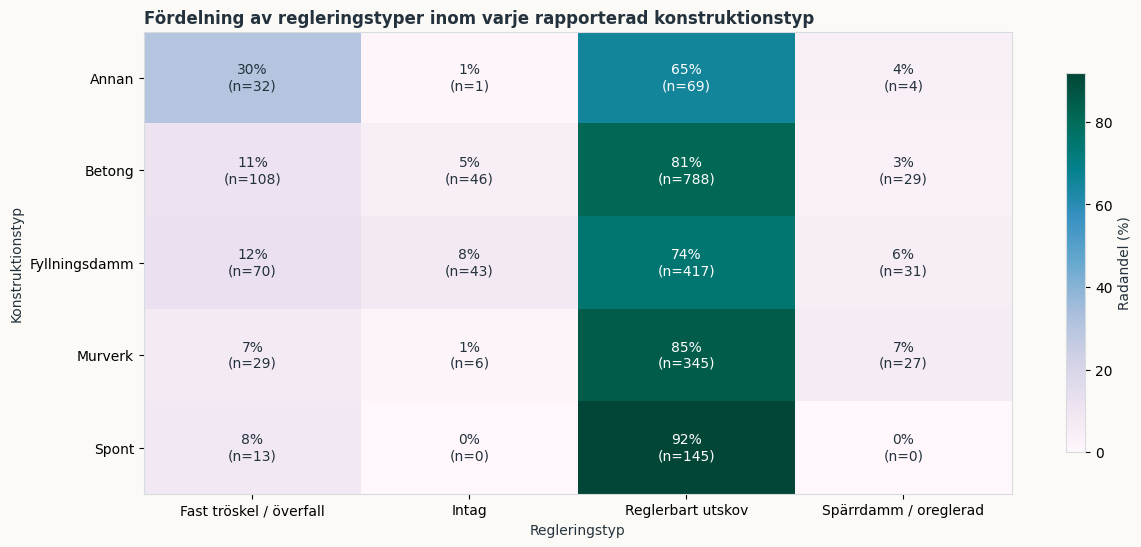

In [215]:
known_types = existing.loc[existing["construction_clean"].ne("Ej angivet") & existing["regulation_clean"].ne("Ej angivet")]
relationship = pd.crosstab(known_types["construction_clean"], known_types["regulation_clean"])
row_share = relationship.div(relationship.sum(axis=1), axis=0).mul(100)
fig, ax = plt.subplots(figsize=(14, 6))
image = ax.imshow(row_share, cmap="PuBuGn", vmin=0, vmax=max(50, row_share.to_numpy().max()), aspect="auto")
ax.set_xticks(range(len(row_share.columns)), row_share.columns, rotation=0, ha="center"); ax.set_yticks(range(len(row_share.index)), row_share.index)
for row in range(row_share.shape[0]):
    for column in range(row_share.shape[1]):
        value = row_share.iat[row, column]
        ax.text(column, row, f"{value:.0f}%\n(n={relationship.iat[row, column]:,})", ha="center", va="center", fontsize=10, color="white" if value > 35 else COLORS["ink"])
ax.set_title("Fördelning av regleringstyper inom varje rapporterad konstruktionstyp", loc="left", weight="bold"); ax.set_xlabel("Regleringstyp"); ax.set_ylabel("Konstruktionstyp")
fig.colorbar(image, ax=ax, label="Radandel (%)", shrink=0.82)

Okända klassificeringar är en del av resultatet, inte brus som ska tas bort i tysthet. Värmekartan är villkorad på att båda fälten är rapporterade och beskriver därför endast den dokumenterade delmängden.

## 7. Dammhöjd och krönlängd / Dam height and crest length

### Avsnittsspecifik rensning / Section-specific cleaning

1. Bevara `dammhojd_raw` och `kron_raw`.
2. Behandla icke-positiva värden som saknade.
3. Flagga höjder över 30 m som ligger inom 2 m från ett positivt `dg` eller `sg` som `sannolik höjdnivå`; de innehåller sannolikt en absolut höjdnivå i stället för konstruktionshöjd.
4. Flagga återstående höjder över 150 m som `extremvärde – granska`. Detta är en granskningsgräns, inte en automatisk korrigering.
5. Behåll positiva krönlängder. Värden över 99,5-percentilen markeras för granskning men behålls eftersom `kron` betyder längd, inte bredd.
6. Imputera inte saknade höjder. Trängslet visar varför externa fakta måste lagras separat med tydlig källa.

In [216]:
dimensions = existing.copy()
height = dimensions["dammhojd_raw"]; crest = dimensions["kron_raw"]
valid_dg = dimensions["dg_raw"].where(dimensions["dg_raw"].gt(0)); valid_sg = dimensions["sg_raw"].where(dimensions["sg_raw"].gt(0))
height_missing = height.isna() | height.le(0)
height_matches_level = height.gt(30) & (height.sub(valid_dg).abs().le(2) | height.sub(valid_sg).abs().le(2))
height_extreme = height.gt(150) & ~height_matches_level
dimensions["height_flag"] = np.select([height_missing, height_matches_level, height_extreme], ["saknas", "sannolik höjdnivå", "extremvärde – granska"], default="användbar")
dimensions["dammhojd_clean"] = height.mask(dimensions["height_flag"].ne("användbar"))
dimensions["kronlangd_clean"] = crest.mask(crest.isna() | crest.le(0))
crest_review_limit = dimensions["kronlangd_clean"].quantile(0.995)
dimensions["crest_flag"] = np.select([dimensions["kronlangd_clean"].isna(), dimensions["kronlangd_clean"].gt(crest_review_limit)], ["saknas", "långt krön – granska"], default="användbar")
audit = dimensions["height_flag"].value_counts().rename_axis("höjdflagga").to_frame("poster"); audit["andel"] = audit["poster"] / len(dimensions)
audit_display = audit.copy(); audit_display["poster"] = audit_display["poster"].map(lambda value: f"{value:,}"); audit_display["andel"] = audit_display["andel"].map(lambda value: f"{value:.1%}")
display(audit_display)
review_rows = dimensions.loc[dimensions["height_flag"].isin(["sannolik höjdnivå", "extremvärde – granska"]), ["display_name", "dammid", "dammhojd_raw", "dg_raw", "sg_raw", "height_flag"]].sort_values("dammhojd_raw", ascending=False)
display(review_rows.rename(columns={"display_name": "namn", "dammhojd_raw": "dammhöjd råvärde", "dg_raw": "dg råvärde", "sg_raw": "sg råvärde", "height_flag": "kvalitetsflagga"}))

,poster,andel
höjdflagga,,
saknas,"6,626",71.3%
användbar,"2,659",28.6%
sannolik höjdnivå,10,0.1%
extremvärde – granska,3,0.0%


,namn,dammid,dammhöjd råvärde,dg råvärde,sg råvärde,kvalitetsflagga
9739,Ramsjön,{073F2C2F-E631-464E-823B-AB30D3082009},335.00,0.00,0.00,extremvärde – granska
6915,ECKERN,{35E7D128-9310-44B8-8A6C-39CFCC310D18},216.00,216.52,215.42,sannolik höjdnivå
9744,Mälarskogs Bevattn.Damm,{D45C5FB6-934A-4595-8B66-D4CBAB1142F3},195.00,0.00,0.00,extremvärde – granska
7162,TORSVIK DAMM,{5F19BBE9-A926-4A04-8B3A-DA94F8E6F374},193.70,193.98,193.20,sannolik höjdnivå
9743,Övre Dammen,{F60412F4-2A68-485C-93DB-CB2F158EB82B},165.00,0.00,0.00,extremvärde – granska
9910,GYLLENFORS,{BF8936D1-CE89-4501-9ABA-E6CBE39ED82C},154.75,153.78,151.12,sannolik höjdnivå
6874,Aspö,{E45BC637-564E-44FF-A170-45E9418C2DB1},143.89,143.94,143.56,sannolik höjdnivå
9839,BRUKSGÅRDEN,{641C7D02-F04F-4957-AB4D-457DBD2A76E8},138.59,138.64,137.96,sannolik höjdnivå
3298,Havets Kvarn,{14B2493B-563A-49B2-9324-593D3EA79935},84.40,84.40,0.00,sannolik höjdnivå
7224,Oxhult,{76C14449-1A3E-4794-AB1A-913B124C9348},78.00,79.00,0.00,sannolik höjdnivå


In [217]:
def normalise_text(value):
    text = "" if pd.isna(value) else str(value)
    return "".join(character for character in unicodedata.normalize("NFKD", text) if not unicodedata.combining(character)).casefold()
trangslet_mask = dimensions["dnamn"].map(normalise_text).str.contains("trangslet", regex=False) | dimensions["namn"].map(normalise_text).str.contains("trangslet", regex=False)
trangslet = dimensions.loc[trangslet_mask, ["dammid", "dnamn", "namn", "dammhojd_raw", "kron_raw", "dg_raw", "sg_raw", "rv_raw", "geometry"]].copy()
display(trangslet)

,dammid,dnamn,namn,dammhojd_raw,kron_raw,dg_raw,sg_raw,rv_raw,geometry
5565,{BDA851F4-EB96-413B-AEBE-B585A0BDB3E8},None,Trängsletdammen,0.0,0.0,422.95,388.0,880.0,POINT (431875.739 6805907.8)


In [227]:
import plotly.express as px
from pathlib import Path
import sys

project_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "_config.yml").exists())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from plotly_book import show_plotly

def robust_sizes(values, minimum=4, maximum=18, quantile=0.99):
    capped = values.clip(upper=values.quantile(quantile)); scaled = np.sqrt(capped)
    if scaled.max() == scaled.min(): return np.full(len(values), minimum)
    return minimum + (maximum - minimum) * (scaled - scaled.min()) / (scaled.max() - scaled.min())

def county_boundary_coordinates(geometries):
    xs, ys = [], []
    for boundary in geometries.boundary:
        lines = boundary.geoms if boundary.geom_type == "MultiLineString" else [boundary]
        for line in lines:
            x_line, y_line = line.xy
            xs.extend(x_line); ys.extend(y_line); xs.append(None); ys.append(None)
    return xs, ys

height_data = dimensions.dropna(subset=["dammhojd_clean"]).copy()
crest_data = dimensions.dropna(subset=["kronlangd_clean"]).copy()
height_review = dimensions[dimensions["height_flag"].isin(["sannolik höjdnivå", "extremvärde – granska"])]
long_crests = crest_data[crest_data["crest_flag"].eq("långt krön – granska")]
border_x, border_y = county_boundary_coordinates(counties.geometry)

dimension_map = make_subplots(rows=1, cols=2, subplot_titles=("Användbara dammhöjder", "Rapporterad krönlängd – inte bredd"), horizontal_spacing=0.08)
for column in (1, 2):
    dimension_map.add_trace(go.Scattergl(x=border_x, y=border_y, mode="lines", line=dict(color="white", width=1), fill="toself", fillcolor=COLORS["water"], hoverinfo="skip", showlegend=False), row=1, col=column)
height_ticks = np.arange(np.floor(np.log10(height_data["dammhojd_clean"].min())), np.ceil(np.log10(height_data["dammhojd_clean"].max())) + 1)
dimension_map.add_trace(go.Scattergl(x=height_data["x"], y=height_data["y"], mode="markers", name="Användbar dammhöjd", customdata=np.column_stack([height_data["display_name"], height_data["dammid"], height_data["dammhojd_clean"]]), marker=dict(size=robust_sizes(height_data["dammhojd_clean"]), color=np.log10(height_data["dammhojd_clean"]), colorscale="Magma_r", opacity=0.72, colorbar=dict(title="Dammhöjd (m)", x=0.46, len=0.65, tickvals=height_ticks, ticktext=[f"{10 ** tick:g}" for tick in height_ticks])), hovertemplate="<b>%{customdata[0]}</b><br>Dammhöjd: %{customdata[2]:.2f} m<extra></extra>"), row=1, col=1)
dimension_map.add_trace(go.Scattergl(x=height_review["x"], y=height_review["y"], mode="markers", name="Behöver granskas", customdata=np.column_stack([height_review["display_name"], height_review["dammid"], height_review["dammhojd_raw"], height_review["height_flag"]]), marker=dict(size=10, symbol="x", color=COLORS["gold"], line=dict(width=1)), hovertemplate="<b>%{customdata[0]}</b><br>Råvärde: %{customdata[2]:.2f} m<br>%{customdata[3]}<extra></extra>"), row=1, col=1)
if not trangslet.empty:
    dimension_map.add_trace(go.Scattergl(x=trangslet.geometry.x, y=trangslet.geometry.y, mode="markers", name="Trängslet · dammhöjd saknas", marker=dict(size=15, symbol="star", color=COLORS["ink"]), hovertemplate="<b>Trängslet</b><br>Dammhöjd saknas i registret<extra></extra>"), row=1, col=1)
crest_ticks = np.arange(np.floor(np.log10(crest_data["kronlangd_clean"].min())), np.ceil(np.log10(crest_data["kronlangd_clean"].max())) + 1)
dimension_map.add_trace(go.Scattergl(x=crest_data["x"], y=crest_data["y"], mode="markers", name="Rapporterad krönlängd", customdata=np.column_stack([crest_data["display_name"], crest_data["dammid"], crest_data["kronlangd_clean"]]), marker=dict(size=robust_sizes(crest_data["kronlangd_clean"]), color=np.log10(crest_data["kronlangd_clean"]), colorscale="PuRd", opacity=0.70, colorbar=dict(title="Krönlängd (m)", x=1.01, len=0.65, tickvals=crest_ticks, ticktext=[f"{10 ** tick:g}" for tick in crest_ticks])), hovertemplate="<b>%{customdata[0]}</b><br>Krönlängd: %{customdata[2]:.1f} m<extra></extra>"), row=1, col=2)
dimension_map.add_trace(go.Scattergl(x=long_crests["x"], y=long_crests["y"], mode="markers", name="Översta 0,5 % · granska", customdata=np.column_stack([long_crests["display_name"], long_crests["dammid"], long_crests["kronlangd_clean"]]), marker=dict(size=13, symbol="circle-open", color=COLORS["gold"], line=dict(width=2)), hovertemplate="<b>%{customdata[0]}</b><br>Krönlängd: %{customdata[2]:.1f} m<extra></extra>"), row=1, col=2)
dimension_map.update_xaxes(visible=False); dimension_map.update_yaxes(visible=False)
dimension_map.update_yaxes(scaleanchor="x", scaleratio=1, row=1, col=1); dimension_map.update_yaxes(scaleanchor="x2", scaleratio=1, row=1, col=2)
dimension_map.update_layout(title="Dimensioner efter semantisk rensning", height=850, template="plotly_white", paper_bgcolor=COLORS["background"], plot_bgcolor=COLORS["background"], legend=dict(orientation="h", y=-0.04), margin=dict(l=20, r=80, t=90, b=80))
dimension_map.write_html(FIGURE_DIR / "05_clean_dimensions_map.html", include_plotlyjs=True)

def log_histogram(values, bins=35):
    edges = np.geomspace(values.min(), values.max(), bins + 1)
    counts, _ = np.histogram(values, bins=edges)
    return np.sqrt(edges[:-1] * edges[1:]), edges, counts

height_centres, height_edges, height_counts = log_histogram(height_data["dammhojd_clean"])
crest_centres, crest_edges, crest_counts = log_histogram(crest_data["kronlangd_clean"])
dimension_histograms = make_subplots(rows=1, cols=2, subplot_titles=("Fördelning av användbara dammhöjder", "Fördelning av rapporterad krönlängd"), horizontal_spacing=0.05)
dimension_histograms.add_trace(go.Bar(x=height_centres, y=height_counts, width=np.diff(height_edges), marker_color=COLORS["rose"], customdata=np.column_stack([height_edges[:-1], height_edges[1:]]), hovertemplate="%{customdata[0]:.2f}–%{customdata[1]:.2f} m<br>Dammenheter: %{y:,}<extra></extra>", name="Dammhöjd"), row=1, col=1)
dimension_histograms.add_trace(go.Bar(x=crest_centres, y=crest_counts, width=np.diff(crest_edges), marker_color=COLORS["purple"], customdata=np.column_stack([crest_edges[:-1], crest_edges[1:]]), hovertemplate="%{customdata[0]:.1f}–%{customdata[1]:.1f} m<br>Dammenheter: %{y:,}<extra></extra>", name="Krönlängd"), row=1, col=2)
dimension_histograms.update_xaxes(type="log", title_text="Dammhöjd (m, logaritmisk axel)", row=1, col=1)
dimension_histograms.update_xaxes(type="log", title_text="Krönlängd (m, logaritmisk axel)", row=1, col=2)
dimension_histograms.update_yaxes(title_text="Dammenheter", row=1, col=1)
dimension_histograms.update_layout(height=470, template="plotly_white", paper_bgcolor=COLORS["background"], plot_bgcolor=COLORS["background"], showlegend=False, bargap=0.04, margin=dict(l=70, r=30, t=70, b=70))
dimension_histograms.write_html(FIGURE_DIR / "06_dimension_distributions.html", include_plotlyjs=True)


show_plotly(dimension_map)
show_plotly(dimension_histograms)

Kartan skiljer mellan saknade, användbara och granskningskrävande värden. Markörstorleken begränsas vid 99-percentilen för läsbarhet utan att det underliggande mätvärdet omdefinieras.

## 8. Fiskvägar och vandringshinder / Fish passages and migration barriers

**Avsnittsspecifik rensning:** `fiskvag=0` betyder ej angivet; `9` betyder uttryckligen att fiskväg saknas; koderna `1`–`8` och `10` anger en rapporterad fiskväg, inklusive okänd eller annan typ. För `vhinder` betyder 0 ej angivet, 1 vandringshinder och 2 inte vandringshinder. Sambandsdiagrammet använder endast poster där båda fälten är rapporterade.

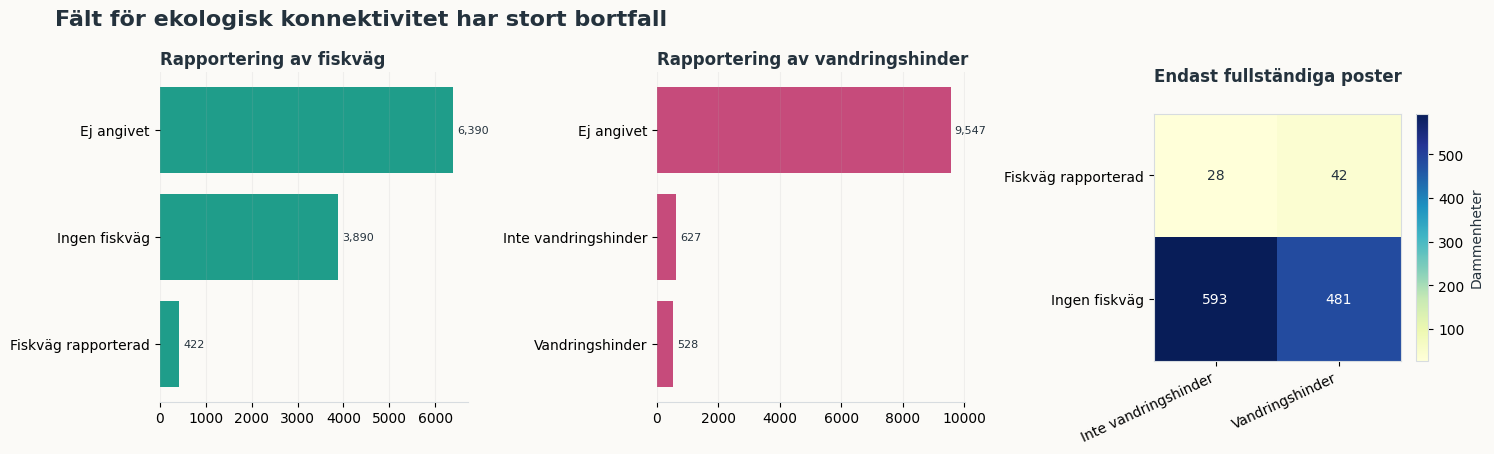

In [219]:
dams["fish_passage_group"] = np.select([dams["fiskvag"].eq(0), dams["fiskvag"].eq(9), dams["fiskvag"].isin([1, 2, 3, 4, 5, 6, 7, 8, 10])], ["Ej angivet", "Ingen fiskväg", "Fiskväg rapporterad"], default="Ogiltig kod")
dams["barrier_group"] = dams["vhinder"].map({0: "Ej angivet", 1: "Vandringshinder", 2: "Inte vandringshinder"}).fillna("Ogiltig kod")
ecology_complete = dams.loc[dams["fish_passage_group"].isin(["Ingen fiskväg", "Fiskväg rapporterad"]) & dams["barrier_group"].isin(["Vandringshinder", "Inte vandringshinder"])]
ecology_table = pd.crosstab(ecology_complete["fish_passage_group"], ecology_complete["barrier_group"])
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
horizontal_counts(axes[0], dams["fish_passage_group"], "Rapportering av fiskväg", COLORS["teal"])
horizontal_counts(axes[1], dams["barrier_group"], "Rapportering av vandringshinder", COLORS["rose"])
image = axes[2].imshow(ecology_table, cmap="YlGnBu"); axes[2].set_xticks(range(len(ecology_table.columns)), ecology_table.columns, rotation=25, ha="right"); axes[2].set_yticks(range(len(ecology_table.index)), ecology_table.index)
for row in range(ecology_table.shape[0]):
    for column in range(ecology_table.shape[1]):
        axes[2].text(column, row, f"{ecology_table.iat[row, column]:,}", ha="center", va="center", color="white" if ecology_table.iat[row, column] > ecology_table.to_numpy().max() / 2 else COLORS["ink"])
axes[2].set_title("Endast fullständiga poster", loc="left", weight="bold", y=1.1); fig.colorbar(image, ax=axes[2], shrink=0.75, label="Dammenheter")
fig.suptitle("Fält för ekologisk konnektivitet har stort bortfall", x=0.04, ha="left", fontsize=16, weight="bold"); fig.tight_layout()
save_figure(fig, "07_fish_passage_barriers.png"); plt.show()

Värmekartan med fullständiga poster är användbar för konsistenskontroll, men får inte generaliseras till alla svenska dammar eftersom de flesta `vhinder`-värden inte är rapporterade.

## 9. Vattendistrikt / River Basin Districts

**Avsnittsspecifik rensning:** extrahera den svenska distriktskoden `SE1`–`SE5` ur standardiserade och gränsöverskridande strängar. Icke-tomma koder utan svenskt distrikt blir `Gränsöverskridande / övrigt`; tomma värden blir `Ej angivet`. Därmed bevaras ovanliga koder som `NO1102`, `NOSE5` och `SE1TO`.

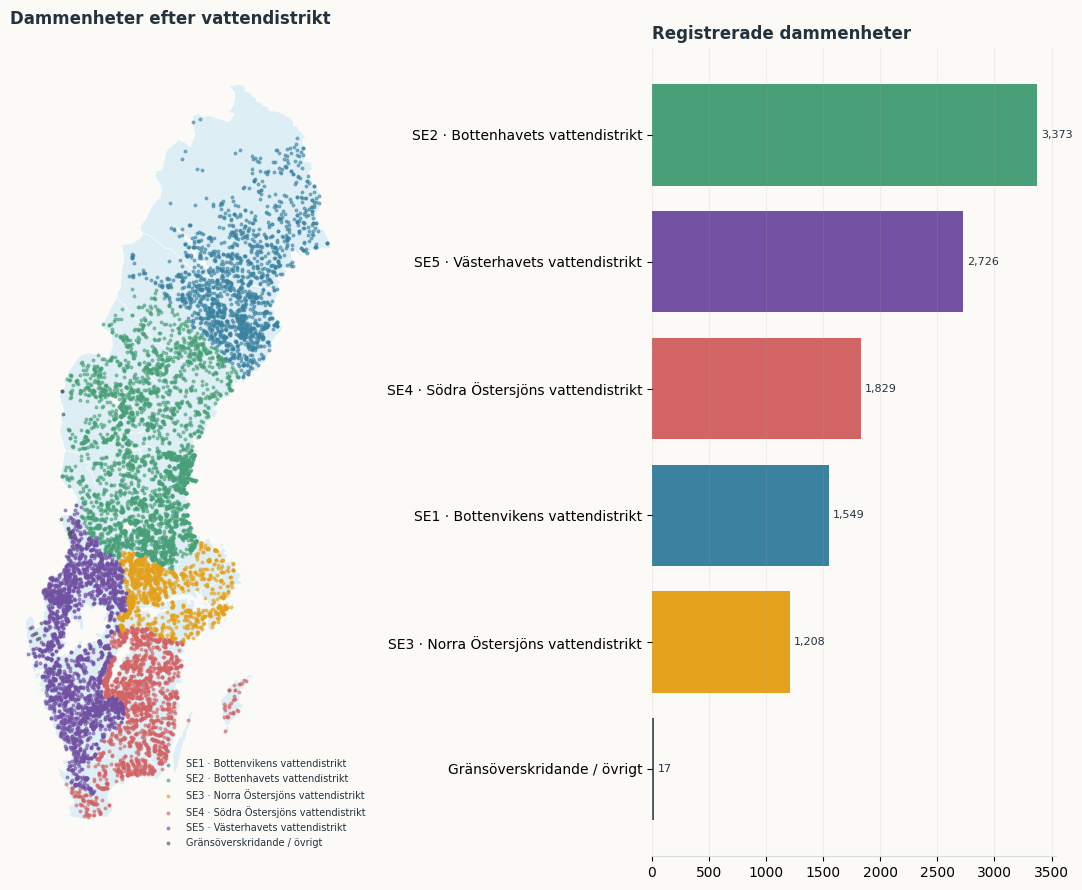

In [220]:
RBD_NAMES = {"SE1": "SE1 · Bottenvikens vattendistrikt", "SE2": "SE2 · Bottenhavets vattendistrikt", "SE3": "SE3 · Norra Östersjöns vattendistrikt", "SE4": "SE4 · Södra Östersjöns vattendistrikt", "SE5": "SE5 · Västerhavets vattendistrikt"}
rbd_text = dams["rbd"].astype("string").str.strip().str.upper(); rbd_code = rbd_text.str.extract(r"(SE[1-5])", expand=False)
dams["rbd_clean"] = rbd_code.map(RBD_NAMES); dams.loc[rbd_text.notna() & dams["rbd_clean"].isna(), "rbd_clean"] = "Gränsöverskridande / övrigt"; dams["rbd_clean"] = dams["rbd_clean"].fillna("Ej angivet")
rbd_palette = {"SE1 · Bottenvikens vattendistrikt": "#3B82A0", "SE2 · Bottenhavets vattendistrikt": "#49A078", "SE3 · Norra Östersjöns vattendistrikt": "#E4A11B", "SE4 · Södra Östersjöns vattendistrikt": "#D26466", "SE5 · Västerhavets vattendistrikt": "#7251A3", "Gränsöverskridande / övrigt": "#4B5563", "Ej angivet": "#C5CBD1"}
fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(12, 9), gridspec_kw={"width_ratios": [1.15, 0.85]})
counties.plot(ax=ax_map, facecolor=COLORS["water"], edgecolor="white", linewidth=0.4)
for label, color in rbd_palette.items():
    subset = dams[dams["rbd_clean"].eq(label)]
    if not subset.empty: subset.plot(ax=ax_map, color=color, markersize=3.5, alpha=0.55, label=label)
ax_map.set_title("Dammenheter efter vattendistrikt", loc="left", weight="bold"); ax_map.set_axis_off(); 
ax_map.legend(frameon=False, fontsize=7, loc="lower right", bbox_to_anchor=(1.08, 0))
counts = dams["rbd_clean"].value_counts().sort_values(); bars = ax_bar.barh(counts.index, counts.values, color=[rbd_palette[label] for label in counts.index]); ax_bar.bar_label(bars, labels=[f"{value:,}" for value in counts.values], padding=3, fontsize=8)
ax_bar.set_title("Registrerade dammenheter", loc="left", weight="bold"); ax_bar.spines[["top", "right", "left"]].set_visible(False); ax_bar.grid(axis="x", alpha=0.15)
fig.tight_layout(); save_figure(fig, "08_river_basin_districts.png"); plt.show()

## 10. Slutsatser och begränsningar / Conclusions and limitations

1. **Bevara ursprunget.** Råfält och rensade fält finns sida vid sida; tveksamma mätvärden flaggas i stället för att skrivas över i tysthet.
2. **Tolka noll per fält.** I denna export fungerar noll ofta som kod för saknat värde. Att behandla noll som ett fysiskt mätvärde skulle snedvrida varje fördelning.
3. **Respektera semantiken.** `kron` är krönlängd. `dg` och `sg` är höjdnivåer. Sammanblandning ger dramatiska men ogiltiga resultat.
4. **Okänt är informativt.** Stora andelar okända värden visar registrets täckningsbegränsningar och förblir synliga i kategoridiagrammen.
5. **Undvik rangordning utan stöd.** Kända anläggningar som Trängslet kan sakna dimensioner i registret. En rangordning av de högsta dammarna kräver en oberoende källbelagd kompletteringstabell.
6. **Skilj beskrivning från nationell inferens.** Rumsliga och kategoriska diagram beskriver registret. Glesa ekologiska fält stöder inte slutsatser om alla svenska dammar.

### Föreslaget nästa steg / Suggested next step

Skapa en granskad kompletteringstabell med `dammid` som nyckel och kolumner för korrigerat värde, mätdefinition, käll-URL, källdatum och granskare. Anslut den endast till analyser som kräver verifierade dimensioner; ersätt aldrig källans DBF-värden.

In [221]:
summary = pd.Series({"Registrerade dammenheter": len(dams), "Befintliga dammenheter": len(existing), "Före detta dammenheter": len(former), "Användbara höjder för befintliga dammar": int(dimensions["dammhojd_clean"].notna().sum()), "Höjdposter som kräver granskning": int(dimensions["height_flag"].isin(["sannolik höjdnivå", "extremvärde – granska"]).sum()), "Behållna positiva krönlängder": int(dimensions["kronlangd_clean"].notna().sum()), "Fiskvägsfält ej angivet": int(dams["fish_passage_group"].eq("Ej angivet").sum()), "Vandringshinderfält ej angivet": int(dams["barrier_group"].eq("Ej angivet").sum())})
display(summary.map(lambda value: f"{value:,}").to_frame("Poster"))

,Poster
Registrerade dammenheter,"10,702"
Befintliga dammenheter,"9,298"
Före detta dammenheter,"1,404"
Användbara höjder för befintliga dammar,"2,659"
Höjdposter som kräver granskning,13
Behållna positiva krönlängder,"2,926"
Fiskvägsfält ej angivet,"6,390"
Vandringshinderfält ej angivet,"9,547"
